**Processamento Digital de Imagens**

Prática de Amostragem e Quantização

Instruções: 
Utilize python e a biblioteca OpenCV para abertura das imagens. 


**Grupo:** G05

1)	Utilizando imagem relogio.tif e faça uma reamostragem de seus pixels para 300, 150 e 72 dpi. Sabe-se que a imagem original possui 1250 dpi. Fazer os cálculos por meio do seu algortimo. Não usar o opencv para a conversão

Tamanho original da imagem: (3692, 2812)
Resolução: 300 DPI - Dimensões obtidas: (886, 675)
Resolução: 150 DPI - Dimensões obtidas: (443, 337)
Resolução: 72 DPI - Dimensões obtidas: (213, 162)


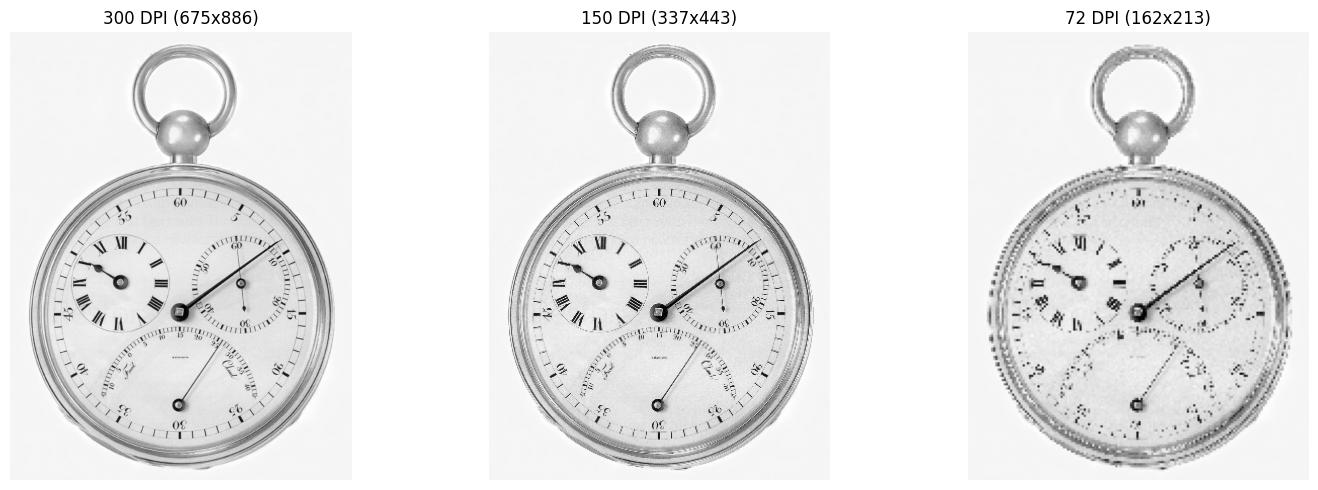

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagem_original = cv2.imread("relogio.tif", cv2.IMREAD_GRAYSCALE)

dpi_original = 1250
dpis_alvo = [300, 150, 72]

# Função para reamostragem 
def reamostrar_imagem(imagem, dpi_orig, dpi_novo):
    linhas_orig, colunas_orig = imagem.shape
    escala = dpi_novo / dpi_orig
    
    # Cálculo das novas dimensões
    novas_linhas = int(round(linhas_orig * escala))
    novas_colunas = int(round(colunas_orig * escala))
    
    # Mapeamento para o vizinho mais próximo
    indices_linhas = np.clip(np.round(np.arange(novas_linhas) / escala).astype(int), 0, linhas_orig - 1)
    indices_colunas = np.clip(np.round(np.arange(novas_colunas) / escala).astype(int), 0, colunas_orig - 1)
    
    # Nova img
    imagem_reamostrada = imagem[np.ix_(indices_linhas, indices_colunas)]
    return imagem_reamostrada

imagens_reamostradas = {}

print("Tamanho original da imagem:", imagem_original.shape)

for dpi in dpis_alvo:
    img_reamostrada = reamostrar_imagem(imagem_original, dpi_original, dpi)
    imagens_reamostradas[dpi] = img_reamostrada
    print(f"Resolução: {dpi} DPI - Dimensões obtidas: {img_reamostrada.shape}")

# Plot
plt.figure(figsize=(15, 5))
for i, dpi in enumerate(dpis_alvo):
    plt.subplot(1, 3, i + 1)
    plt.imshow(imagens_reamostradas[dpi], cmap='gray', vmin=0, vmax=255)
    plt.title(f"{dpi} DPI ({imagens_reamostradas[dpi].shape[1]}x{imagens_reamostradas[dpi].shape[0]})")
    plt.axis('off')
plt.tight_layout()
plt.show()

2)	Utilizando a imagem ctskull-256.tif, refaça a quantização de seus pixels utilizando de 7 a 1 bit(s) por pixel.  Fazer os cálculos por meio do seu algortimo. Não usar o opencv para a conversão

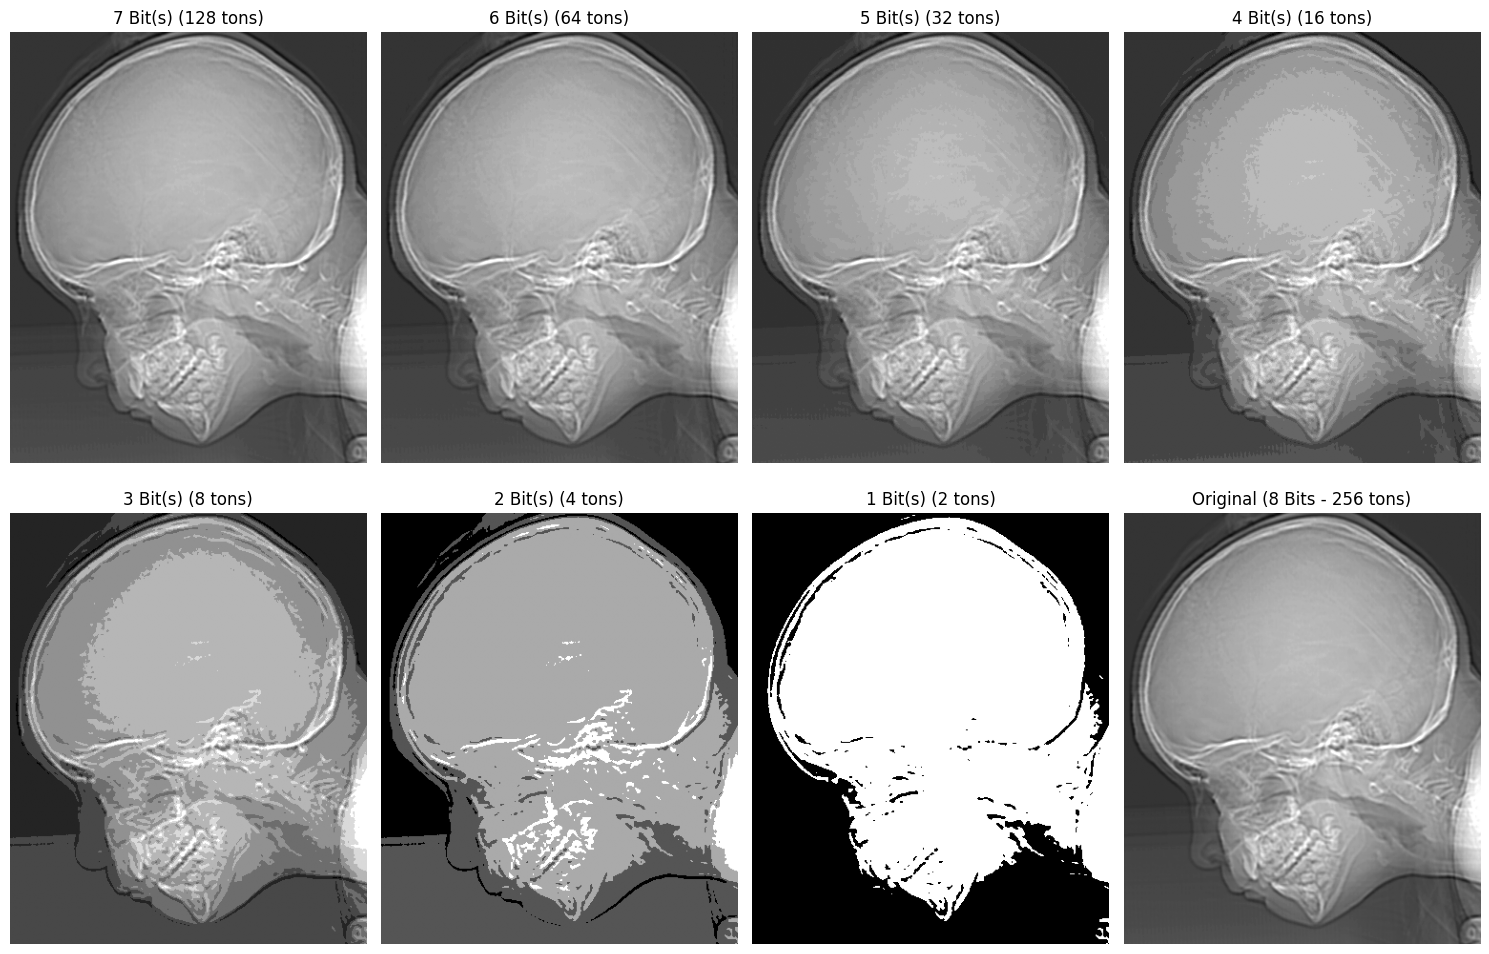

In [ ]:
# Carregar imagem em tons de cinza
imagem_skull = cv2.imread("ctskull-256.tif", cv2.IMREAD_GRAYSCALE)

# Função de quantização personalizada
def quantizar_imagem(imagem, bits):
    niveis = 2**bits
    intervalo = 256 / niveis
    # Quantização por truncamento mapeada de volta para a escala de 0 a 255
    imagem_quantizada = np.floor(imagem / intervalo) * (255 / (niveis - 1))
    return imagem_quantizada.astype(np.uint8)

# Aplicar quantização de 7 a 1 bits e plotar os resultados
plt.figure(figsize=(15, 10))
for bits in range(7, 0, -1):
    img_quant = quantizar_imagem(imagem_skull, bits)
    
    plt.subplot(2, 4, 8 - bits)
    plt.imshow(img_quant, cmap='gray', vmin=0, vmax=255)
    plt.title(f"{bits} Bit(s) ({2**bits} tons)")
    plt.axis('off')

# Original para comparação
plt.subplot(2, 4, 8)
plt.imshow(imagem_skull, cmap='gray', vmin=0, vmax=255)
plt.title("Original (8 Bits - 256 tons)")
plt.axis('off')

plt.tight_layout()
plt.show()